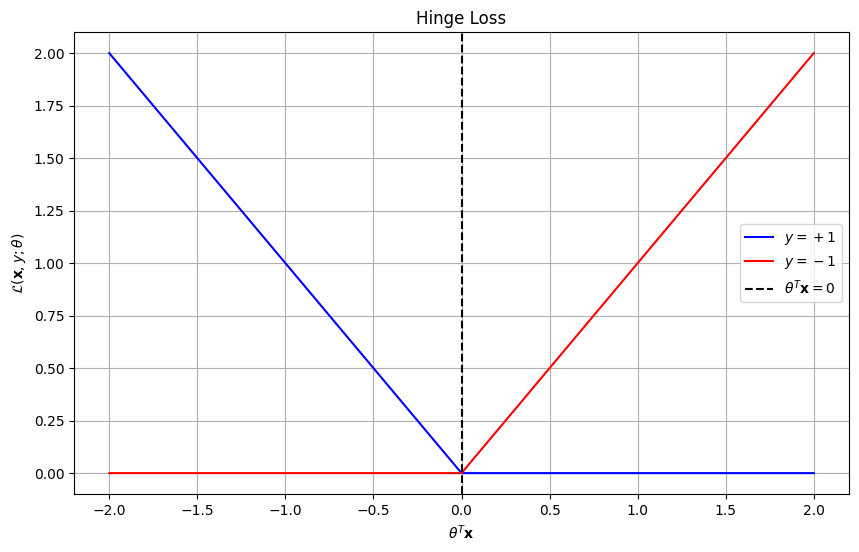

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the hinge loss function
def hinge_loss(theta_x, y):
    return np.maximum(0, -y * theta_x)

# Generate a range of theta^T x values
theta_x_values = np.linspace(-2, 2, 400)

# Calculate hinge loss for y = 1 and y = -1
hinge_loss_y1 = hinge_loss(theta_x_values, 1)
hinge_loss_y_minus1 = hinge_loss(theta_x_values, -1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(theta_x_values, hinge_loss_y1, label=r'$y = +1$', color='blue')
plt.plot(theta_x_values, hinge_loss_y_minus1, label=r'$y = -1$', color='red')
plt.axvline(x=0, color='black', linestyle='--', label=r'$ \theta^T \mathbf{x} = 0$')
plt.title("Hinge Loss")
plt.xlabel(r'$ \theta^T \mathbf{x}$')
plt.ylabel(r'$\mathcal{L}(\mathbf{x}, y; \theta)$')
plt.grid(True)
plt.legend()
plt.show()


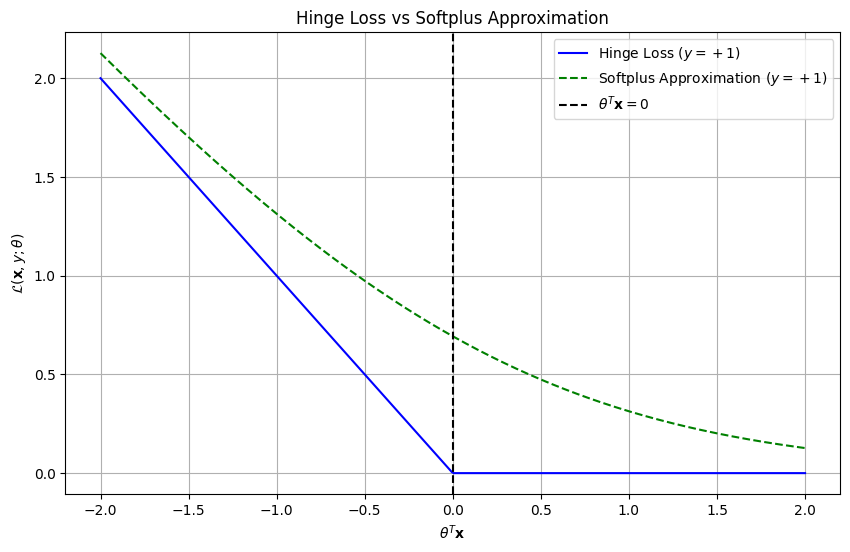

In [ ]:
# Define the hinge loss function
def hinge_loss(theta_x, y):
    return np.maximum(0, -y * theta_x)

# Define the Softplus function approximation for hinge loss
def softplus_approximation(theta_x, y):
    return np.log(1 + np.exp(-y * theta_x))

# Generate a range of theta^T x values
theta_x_values = np.linspace(-2, 2, 400)

# Calculate hinge loss and Softplus approximation for y = 1
hinge_loss_y1 = hinge_loss(theta_x_values, 1)
softplus_y1 = softplus_approximation(theta_x_values, 1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(theta_x_values, hinge_loss_y1, label=r'Hinge Loss ($y = +1$)', color='blue')
plt.plot(theta_x_values, softplus_y1, label=r'Softplus Approximation ($y = +1$)', color='green', linestyle='--')
plt.axvline(x=0, color='black', linestyle='--', label=r'$ \theta^T \mathbf{x} = 0$')
plt.title("Hinge Loss vs Softplus Approximation")
plt.xlabel(r'$ \theta^T \mathbf{x}$')
plt.ylabel(r'$\mathcal{L}(\mathbf{x}, y; \theta)$')
plt.grid(True)
plt.legend()
plt.show()

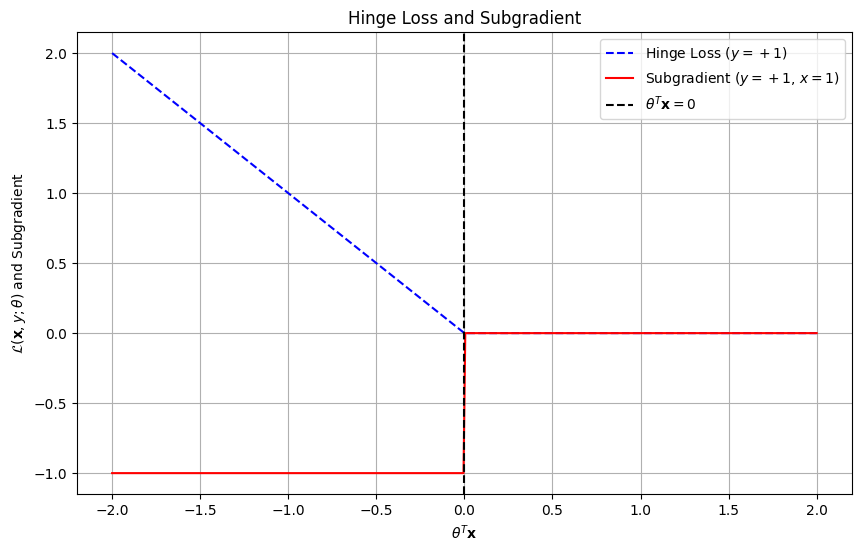

In [ ]:
# Define the subgradient of the hinge loss function
def hinge_loss_subgradient(theta_x, y):
    return np.where(-y * theta_x > 0, -y, 0)

# Generate a range of theta^T x values
theta_x_values = np.linspace(-2, 2, 400)

# Calculate hinge loss and its subgradient for y = 1
hinge_loss_y1 = hinge_loss(theta_x_values, 1)
subgradient_y1 = hinge_loss_subgradient(theta_x_values, 1)

# Plotting
plt.figure(figsize=(10, 6))

# Hinge Loss
plt.plot(theta_x_values, hinge_loss_y1, label=r'Hinge Loss ($y = +1$)', color='blue', linestyle='--')

# Subgradient of the Hinge Loss
plt.plot(theta_x_values, subgradient_y1, label=r'Subgradient ($y = +1$, $x=1$)', color='red')

# Decision Boundary
plt.axvline(x=0, color='black', linestyle='--', label=r'$ \theta^T \mathbf{x} = 0$')

plt.title("Hinge Loss and Subgradient")
plt.xlabel(r'$ \theta^T \mathbf{x}$')
plt.ylabel(r'$\mathcal{L}(\mathbf{x}, y; \theta)$ and Subgradient')
plt.grid(True)
plt.legend()
plt.show()

## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

## Decision Boundary Form (`\theta^T x = b`)\nFor linear classification, the decision boundary can be written as `\theta^T x = b`.\nEquivalently, define score `s = \theta^T x - b`; then the boundary is `s = 0`.\nThe interactive plot below uses this form directly.\n

## Interactive Hinge Loss Explorer
Use the controls to explore all three Lecture 3 hinge-loss figures with a bias term in the score \\((\theta^T x - b)\\).


In [ ]:
# INTERACTIVE_WIDGET_SECTION
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Score form with bias: s = theta^T x - b
def _hinge(score, y=1.0, margin=0.0):
    return np.maximum(0.0, margin - y * score)

def _softplus(score, y=1.0, margin=0.0, tau=1.0):
    z = (margin - y * score) / max(tau, 1e-6)
    return tau * np.log1p(np.exp(z))

def _subgrad(score, y=1.0, margin=0.0):
    return np.where(margin - y * score > 0, -y, 0.0)

def _plot_hinge_family(view='Hinge loss', y=1, b=0.0, margin=0.0, tau=0.3):
    theta_tx = np.linspace(-3.0, 3.0, 600)
    score = theta_tx - b

    plt.figure(figsize=(8, 5))

    if view == 'Hinge loss':
        hl = _hinge(score, y=y, margin=margin)
        plt.plot(theta_tx, hl, lw=2, color='tab:blue', label=f'Hinge loss (y={y})')
        plt.ylabel('loss')
        plt.title(r'Hinge Loss with Bias: $s=\theta^T x - b$')

    elif view == 'Hinge vs Softplus':
        hl = _hinge(score, y=y, margin=margin)
        sp = _softplus(score, y=y, margin=margin, tau=tau)
        plt.plot(theta_tx, hl, lw=2, color='tab:blue', label='Hinge')
        plt.plot(theta_tx, sp, lw=2, color='tab:green', linestyle='--', label=f'Softplus (tau={tau:.2f})')
        plt.ylabel('loss')
        plt.title(r'Hinge vs Softplus with Bias: $s=\theta^T x - b$')

    else:
        hl = _hinge(score, y=y, margin=margin)
        sg = _subgrad(score, y=y, margin=margin)
        plt.plot(theta_tx, hl, lw=2, color='tab:blue', linestyle='--', label='Hinge')
        plt.plot(theta_tx, sg, lw=2, color='tab:red', label='Subgradient')
        plt.ylabel('hinge / subgradient')
        plt.title(r'Hinge Subgradient with Bias: $s=\theta^T x - b$')

    boundary = b + margin / y
    plt.axvline(boundary, color='black', linestyle='--', label='margin kink')
    plt.axvline(b, color='gray', linestyle=':', label=r'$\theta^T x=b$')
    plt.xlabel(r'$\theta^T x$')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

widgets.interact(
    _plot_hinge_family,
    view=widgets.ToggleButtons(
        options=['Hinge loss', 'Hinge vs Softplus', 'Subgradient'],
        value='Hinge loss',
        description='figure'
    ),
    y=widgets.ToggleButtons(options=[-1, 1], value=1, description='label y'),
    b=widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='bias b'),
    margin=widgets.FloatSlider(value=0.0, min=0.0, max=2.0, step=0.1, description='margin'),
    tau=widgets.FloatSlider(value=0.3, min=0.05, max=1.5, step=0.05, description='softplus tau')
)
